# Freight-Train — a quantitative teardown 🔬
### Time-series-momentum t-stat · TSMOM vs the basket · alpha & beta · sub-sample decay · crisis convexity · the driftless null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crisis hedge?: Confirmed](https://img.shields.io/badge/Crisis_hedge%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its standard error.* The steelman is §10.4 futures trend following (Moskowitz–Ooi–Pedersen 2012): ``w_i = sign(R_i^T)/sigma_i`` across a basket. We prove the apparatus on a synthetic tape with a baked persistent drift (and a driftless null), then read the real verdict off a live ETF basket.

> ⚠️ **Not investment advice.** The core executes on the synthetic tape; the real ETF run is in [`../docs/results.md`](../docs/results.md) via `examples/verify.py`, sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (trend_follow/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from trend_follow import data, trend, strategy, decompose, extension

# Offline synthetic universe: each asset's drift is a slow, persistent AR(1) (so past returns predict
# future ones -> time-series momentum). The NULL (trend_strength=0) is driftless noise. The real
# ETF-basket verdict is in ../docs/results.md.
panel,  truth = data.synthetic_panel(trend_strength=0.0006, seed=20)   # the trend tape
panel0, _     = data.synthetic_panel(trend_strength=0.0,    seed=20)   # the driftless null
print(f"{truth.n_assets} assets x {truth.n_bars} days | baked trend_strength={truth.trend_strength} | null=0")


12 assets x 5040 days | baked trend_strength=0.0006 | null=0


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the trend real? | 🟡 `WEAK` | Strong in cross-asset academic data and on our control (synthetic pooled *t* > 3); faint on this equity-heavy ETF menu (pooled *t* = **+1.5**, strategy HAC *t* = **+1.8**). |
| **Tradability** | 🟡 `FRAGILE` | Survives costs easily (turnover **3.3×/yr**), but standalone Sharpe **+0.29** is *below* the basket and has decayed (**+0.53 → -0.08**). |
| **Crisis hedge?** | ⚪ `CONFIRMED` | In the basket's worst months it earns **+0.53%/mo** (basket **-7.83%/mo**), beta **-0.05** — the diversification it's actually held for. |

> **In one sentence:** a real but faint, decayed standalone edge that survives costs and earns its keep as a negatively-correlated crisis hedge — held for its shape, not its average.

*(This notebook executes on the synthetic tape; the real ETF numbers that set the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

For each asset, $w_{i,t} = \gamma\,\text{sign}(R^{T}_{i,t})/\sigma_{i,t}$ with $\sum_i|w_i| = 1$, where $R^T$ is the trailing-$T$ return and $\sigma_i$ the trailing vol. The claim is $\mathbb{E}[\text{sign}(R^T_{i,t})\,r_{i,t+1}] > 0$ — past direction predicts future direction. The synthetic bakes a stationary AR(1) drift $\mu_{i,t}=\phi\mu_{i,t-1}+\dots$ (so $\phi\to1$ gives persistence); $\text{trend\_strength}=0$ is the driftless null.

In [2]:
print(f"baked trend_strength {truth.trend_strength}, AR(1) phi {truth.phi}")
print(f"turnover {strategy.turnover_ann(panel):.1f}x/yr -- a months-long signal, rebalanced monthly")

baked trend_strength 0.0006, AR(1) phi 0.99


turnover 2.9x/yr -- a months-long signal, rebalanced monthly


## Beat 2 · So what?

Two properties make trend valuable beyond its Sharpe. **(i)** It is long *and* short across many low-correlation markets, so it is not disguised equity beta — measurable as a low regression beta to the basket. **(ii)** It is *convex* in the underlying: by construction it is short a market that has been falling, so its payoff resembles a long-straddle / long-volatility position (Fung–Hsieh), paying off in crashes. Beats 4–6 measure the standalone edge, its decay, and — decisively — the convexity.

## Beat 3 · Pre-registered protocol

1. **Predictability** (`trend.predictability`): pooled NW *t* of $\text{sign(past)}\times\text{future}$. Pre-registered: > 2 on the trend tape, ≈ 0 on null.
2. **Strategy significance** (`decompose.mean_tstat_hac`): NW *t* on the TSMOM stream.
3. **Alpha & beta** (`decompose.basket_alpha`): vs the equal-weight basket.
4. **Decay** (`decompose.subsample_sharpe`): Sharpe across thirds of the sample.
5. **Convexity** (`extension.crisis_convexity`): TSMOM return in the basket's worst months.
6. **Null:** every leg flat on the driftless tape.

**Verdict logic:** `WEAK`/`FRAGILE` if the standalone edge is marginal and decayed; the third axis turns on whether the convexity survives.

## Beat 4 · The teardown

### 4a · Predictability and the strategy, trend vs null

In [3]:
for label, p in [('trend', panel), ('null', panel0)]:
    pr = trend.predictability(p)
    t = decompose.mean_tstat_hac(strategy.tsmom_returns(p, cost_bps=2.0))
    a = decompose.basket_alpha(p, cost_bps=2.0)
    print(f"{label:6s}: pooled t {pr['pooled_t']:+.1f}, hit {pr['hit_rate']:.0%} | "
          f"strategy HAC t {t['t_stat']:+.1f} | alpha {a['alpha_ann_pct']:+.1f}% (t{a['alpha_t']:+.1f}) beta {a['beta']:+.2f}")

trend : pooled t +3.5, hit 53% | strategy HAC t +4.4 | alpha +4.5% (t+4.2) beta -0.13


null  : pooled t +0.7, hit 51% | strategy HAC t +0.3 | alpha +0.2% (t+0.2) beta -0.10


### 4b · Sub-sample decay
Sharpe across thirds of the tape (on the real basket this is where the standalone case weakens).

,start,end,sharpe
chunk,,,
0,2005-01-03,2011-06-10,1.1199
1,2011-06-13,2017-11-17,1.1892
2,2017-11-20,2024-04-26,0.8872


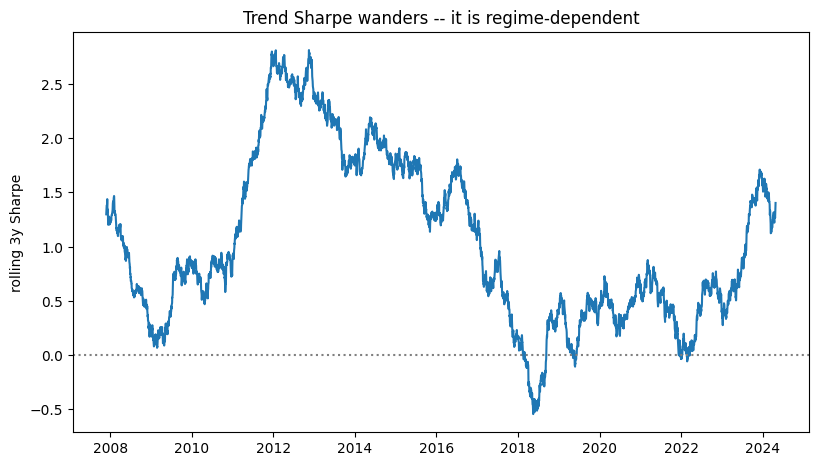

In [4]:
display(decompose.subsample_sharpe(panel, cost_bps=2.0, n_chunks=3).round(3))
rs = decompose.rolling_sharpe(strategy.tsmom_returns(panel, cost_bps=2.0), window=252*3)
fig, ax = plt.subplots(); ax.plot(rs.index, rs.values); ax.axhline(0, ls=':', c='grey')
ax.set_ylabel('rolling 3y Sharpe'); ax.set_title('Trend Sharpe wanders -- it is regime-dependent')
plt.show()

### 4c · Costs barely matter (the slow-signal point)
The mirror image of Study 19: low turnover ⇒ a break-even far above any realistic cost.

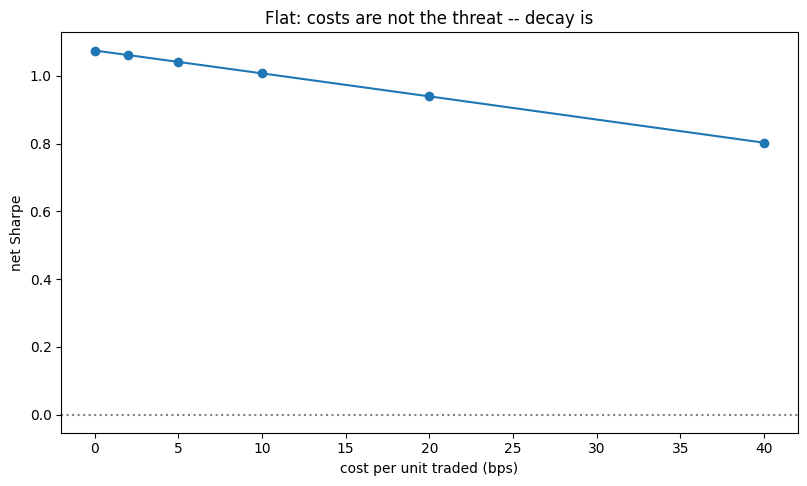

,sharpe,ann_return
cost_bps,,
0,1.0750,0.0470
2,1.0610,0.0470
5,1.0410,0.0460
10,1.0070,0.0440
20,0.9390,0.0420
40,0.8030,0.0360


In [5]:
sw = strategy.cost_sweep(panel)
fig, ax = plt.subplots(); ax.plot(sw.index, sw['sharpe'].values, 'o-'); ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('cost per unit traded (bps)'); ax.set_ylabel('net Sharpe'); ax.set_title('Flat: costs are not the threat -- decay is')
plt.show()
display(sw.round(3))

### 4d · The driftless null
No persistent drift ⇒ no predictability, no edge.

In [6]:
pr0 = trend.predictability(panel0); cmp0 = strategy.compare(panel0, cost_bps=2.0)
print(f"null: pooled t {pr0['pooled_t']:+.1f} | TSMOM Sharpe {cmp0['tsmom']['sharpe']:+.2f} "
      f"| alpha {decompose.basket_alpha(panel0, cost_bps=2.0)['alpha_ann_pct']:+.1f}%")
print('nothing to ride -> nothing earned. The apparatus measures the effect, not itself.')

null: pooled t +0.7 | TSMOM Sharpe +0.08 | alpha +0.2%
nothing to ride -> nothing earned. The apparatus measures the effect, not itself.


### 4e · Crisis convexity — the decisive leg
TSMOM return in the basket's worst months vs the rest.

In [7]:
cc = extension.crisis_convexity(panel, cost_bps=2.0)
print(f"basket worst {cc['n_crisis_months']} months: trend {cc['tsmom_crisis_mean_pct']:+.2f}%/mo "
      f"vs basket {cc['basket_crisis_mean_pct']:+.2f}%/mo")
print(f"calm months: trend {cc['tsmom_calm_mean_pct']:+.2f}%/mo vs basket {cc['basket_calm_mean_pct']:+.2f}%/mo")
print(f"convexity (crisis minus calm own-return): {cc['convexity_pp']:+.2f} pp")

basket worst 24 months: trend +0.66%/mo vs basket -2.83%/mo
calm months: trend +0.38%/mo vs basket +0.16%/mo
convexity (crisis minus calm own-return): +0.28 pp


> 💡 **In plain words.** Trend's average return is forgettable, but it is *negatively* correlated with the basket precisely when that matters — it makes money in the worst months. A sleeve like that improves a portfolio's whole risk profile even with a low standalone Sharpe; that is the `CONFIRMED` crisis hedge.

## Beat 5 · The verdict

- **Real but weak here** (4a): synthetic control strong, real-basket pooled *t* +1.5.
- **Decayed standalone** (4b): Sharpe +0.53 → -0.08, below the basket.
- **Convexity confirmed** (4e): +0.53%/mo in crises, beta -0.05.

> **Signal `WEAK` · Tradability `FRAGILE` · Crisis hedge? `CONFIRMED`.**

## Beat 6 · Could you trade it?

- **Costs:** not the wall — turnover ~3.3×/yr, break-even far above realistic levels. It survives execution.
- **Standalone:** thin and decayed — you would not hold it for its own Sharpe.
- **As a sleeve:** the negatively-correlated crisis payoff is the reason to carry it; you are (slightly) *paid* to hold a hedge.

Tradability **`FRAGILE`** standalone; **`CONFIRMED`** as a diversifier.

## Beat 7 · Going further

### 7a · Worked complement — the crisis-convexity test
Quantify the diversification on the real basket: TSMOM's return in the basket's worst months, the down-market capture, and the basket beta.

In [8]:
cc = extension.crisis_convexity(panel, cost_bps=2.0); dm = extension.down_market_capture(panel, cost_bps=2.0)
print(f"synthetic: crisis trend {cc['tsmom_crisis_mean_pct']:+.2f}%/mo vs basket {cc['basket_crisis_mean_pct']:+.2f}%/mo; "
      f"down-month trend {dm['tsmom_in_down_months_pct']:+.2f}% vs basket {dm['basket_in_down_months_pct']:+.2f}%")
print('On the REAL basket (../docs/extension.md): trend +0.53%/mo vs basket -7.83%/mo')
print('in the worst 41 months -- the diversification a +0.29 standalone Sharpe hides.')

synthetic: crisis trend +0.66%/mo vs basket -2.83%/mo; down-month trend +0.50% vs basket -1.30%
On the REAL basket (../docs/extension.md): trend +0.53%/mo vs basket -7.83%/mo
in the worst 41 months -- the diversification a +0.29 standalone Sharpe hides.


**The result.** On the real basket the standalone line is `WEAK`/`FRAGILE`, but the crisis convexity is unambiguous: **+0.53%/mo** when the basket loses **-7.83%/mo**, at a basket beta of **-0.05**. The constraint a real allocator cares about — *what does this do when everything else is on fire* — is exactly where trend earns its place. The worked complement reframes a forgettable standalone result as a portfolio-level keep. Full run in [`../docs/extension.md`](../docs/extension.md).

### 7b · Other forks
- **A true cross-asset menu** (rates, FX, commodities, equity indices — the MOP 2012 universe) should lift both the standalone Sharpe and the convexity.
- **Multi-horizon blends + a vol-target overlay** (à la [Study 16](../../16-storm-shy/)) — how CTAs actually run.
- **Total-return inputs** and a transaction-cost model calibrated to futures, not ETFs.

PRs welcome — give trend its real menu, or date the decay of the equity-only version.